<a href="https://colab.research.google.com/github/qhansen628/FMRI_Similarity_CNN/blob/Collecting-updates-2025/Copy_of_FMRI_Decoding_workshop.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Tutorial source: https://nilearn.github.io/auto_examples/plot_decoding_tutorial.html

In [2]:
!pip install nilearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.7/12.7 MB 66.3 MB/s eta 0:00:00


In [3]:
from nilearn import datasets, plotting
from nilearn.decoding import Decoder
from nilearn.image import mean_img, index_img
import pandas as pd
import numpy as np

# Import dataset


Data description sources: http://dev.pymvpa.org/datadb/haxby2001.html
- 6 subjects (we're only going to import subject 2)
- 12 runs per subject
  - **Each run**, the subjects passively viewed greyscale images of eight object categories (house, cat, object, face...)
  - grouped in 24s **blocks** separated by rest periods.
    - during the stimulus block each image was shown for 500ms and was followed by a 1500ms inter-stimulus interval.
  - Full-brain fMRI data were recorded with a volume repetition time of 2.5s,
  - thus, a stimulus block was covered by roughly 9 volumes

In [7]:
# By default 2nd subject will be fetched
haxby_dataset = datasets.fetch_haxby(subjects=[1,2,3,4,5,6],fetch_stimuli=True)
# 'func' is a list of filenames: one for each subject
fmri_filename = haxby_dataset.func[0]

# print basic information on the dataset
print(haxby_dataset.description)



[fetch_haxby] Added README.md to /root/nilearn_data

[fetch_haxby] Dataset created in /root/nilearn_data/haxby2001

[fetch_haxby] Downloading data from https://www.nitrc.org/frs/download.php/7868/mask.nii.gz ...

[fetch_haxby]  ...done. (0 seconds, 0 min)

[fetch_haxby] Downloading data from http://data.pymvpa.org/datasets/haxby2001/MD5SUMS ...

...

[fetch_haxby] Downloading data from http://data.pymvpa.org/datasets/haxby2001/stimuli-2010.01.14.tar.gz ...

[fetch_haxby]  ...done. (0 seconds, 0 min)

[fetch_haxby] Extracting data from 
/root/nilearn_data/haxby2001/ee9e0d5a40146477e9197f0d13da9b32/stimuli-2010.01.14.tar.gz...

[fetch_haxby] .. done.

.. _haxby_dataset:

Haxby dataset

Access
------
See :func:`nilearn.datasets.fetch_haxby`.

Notes
-----
Results from a classical :term:`fMRI` study that investigated the differences between
the neural correlates of face versus object processing in the ventral visual
stream. Face and object stimuli showed widely distributed and overlapping
response patterns.

See :footcite:t:`Haxby2001`.

Content
-------
The "simple" dataset includes:
    :'func': Nifti images with bold data
    :'session_target': Text file containing run data
    :'mask': Nifti images with employed mask
    :'session': Text file with condition labels

The full dataset additionally includes
    :'anat': Nifti images with anatomical image
    :'func': Nifti images with bold data
    :'mask_vt': Nifti images with mask for ventral visual/temporal cortex
    :'mask_face': Nifti images with face-reponsive brain regions
    :'mask_house': Nifti images with house-reponsive brain regions
    :'mask_face_little': Spatially more 

# Feature extraction: Get ROI and visualize anatomical image
*roi = region of interest*

The object recognition in the brain is done in areas of the ventral temporal cortex
  - includes areas such as the fusiform face area
    - damage to the fusiform face area is thought to cause Prosopagnosia (the inability to recognize faces)
  - The study done by haxby et. al (where the data comes from) demonstrated that organization of object class in the brain isn't actually localized in one region
    - the brain actually encodes objects with sparse distributed representations

By compairing fmri data when subjects viewed scrambled versions (wouldn't result in object recognition activity) of the images compaired to regular images and using some statistical analysis haxby et. al found a subset of voxels which encode the sparse distributed representations


## Get mask and visualize anatomical structure
- get ventral temporal (vt) mask from haxby_dataset
- use plotting.plot_roi
  - input mask file and anatomical image


If you click and drag on the plot you can view different slices


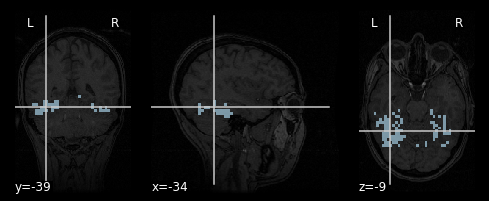

In [ ]:
# get mask of ventral temporal area provided in dataset
mask_filename = haxby_dataset.mask_vt[0]
# visualize the subject's anatomical image with the voxels in the roi coloured blue
plotting.plot_roi(mask_filename, bg_img=haxby_dataset.anat[0],
                  cmap='Paired')

## Load behavioural labels

1. get session_target
2. get labels from session target



In [ ]:
# Load behavioral information
behavioral = pd.read_csv(haxby_dataset.session_target[0], delimiter=' ')


In [ ]:
conditions = behavioral['labels']
print(conditions[4:17])

4         rest
5         rest
6     scissors
7     scissors
8     scissors
9     scissors
10    scissors
11    scissors
12    scissors
13    scissors
14    scissors
15        rest
16        rest
Name: labels, dtype: object


# Restrict to two classes
- we want to know if the subject was viewing a face or a cat
- use conditions.isin to get a condition mask
  - this is used to get only the data samples of interest
  



In [ ]:
condition_mask = conditions.isin(['face', 'cat'])

### Divide the fmri data
- the fmri data is a 4d array (voxels by time)
- we want to divide this into chunks and exclude rest scans, and any stimuli other than cats and faces

Use index_img, input fmri_filename and conditions_mask

In [ ]:
# get chunks of fmri images which are labeled either cat or face
fmri_niimgs = index_img(fmri_filename, condition_mask)
print(fmri_niimgs.shape)


(40, 64, 64, 216)


### get the corresponding labels
1. use the condition_mask to get the relevant labels from conditions
2. get np array of label values

In [ ]:
# apply the same mask to the labels
conditions = conditions[condition_mask]
# Convert to numpy array
conditions = conditions.values
print(conditions.shape)

(216,)


# Decode with SVM

- use KFold cross validation
  - train and test 5 different models
    - withhold different test set for each model
  - this ensures that the model isn't just overfitting

1. import Kfold from sklearn to get 5 different train test splits
2. itterate over each train test split
  - use Decoder to define SVM
  - fit SVM to fmri data to predict correct labels
  - print test accuracy for the model (this repeats 5 times)



In [ ]:
from sklearn.model_selection import KFold
cv = KFold(n_splits=5)

# The "cv" object's split method can now accept data and create a
# generator which can yield the splits.
fold = 0
for train, test in cv.split(conditions):
    fold += 1
    decoder = Decoder(estimator='svc', mask=mask_filename, standardize=True)
    decoder.fit(index_img(fmri_niimgs, train), conditions[train])
    prediction = decoder.predict(index_img(fmri_niimgs, test))
    print(
        "CV Fold {:01d} | Prediction Accuracy: {:.3f}".format(
            fold,
            (prediction == conditions[test]).sum() / float(len(
                conditions[test]))))

/usr/local/lib/python3.7/dist-packages/nilearn/image/resampling.py:453: UserWarning: The provided image has no sform in its header. Please check the provided file. Results may not be as expected.
  warnings.warn("The provided image has no sform in its header. "


CV Fold 1 | Prediction Accuracy: 0.886


/usr/local/lib/python3.7/dist-packages/nilearn/image/resampling.py:453: UserWarning: The provided image has no sform in its header. Please check the provided file. Results may not be as expected.
  warnings.warn("The provided image has no sform in its header. "


CV Fold 2 | Prediction Accuracy: 0.767


/usr/local/lib/python3.7/dist-packages/nilearn/image/resampling.py:453: UserWarning: The provided image has no sform in its header. Please check the provided file. Results may not be as expected.
  warnings.warn("The provided image has no sform in its header. "


CV Fold 3 | Prediction Accuracy: 0.767


/usr/local/lib/python3.7/dist-packages/nilearn/image/resampling.py:453: UserWarning: The provided image has no sform in its header. Please check the provided file. Results may not be as expected.
  warnings.warn("The provided image has no sform in its header. "


CV Fold 4 | Prediction Accuracy: 0.698


/usr/local/lib/python3.7/dist-packages/nilearn/image/resampling.py:453: UserWarning: The provided image has no sform in its header. Please check the provided file. Results may not be as expected.
  warnings.warn("The provided image has no sform in its header. "


CV Fold 5 | Prediction Accuracy: 0.744


In [ ]:
plotting.view_img(
    decoder.coef_img_['face'], bg_img=haxby_dataset.anat[0],
    title="SVM weights", dim=-1
)

In [ ]:
conditions = conditions[condition_mask]
# Convert to numpy array
conditions = conditions.values
#print(conditions.shape)#

In [ ]:
n_folds = 5
decoder = Decoder(
    estimator='svc', mask=mask_filename,
    standardize=True, cv=n_folds,
    scoring='accuracy'
)
decoder.fit(fmri_niimgs, conditions)

In [ ]:
coef_ = decoder.coef_


In [ ]:
decoder.coef_img_['face'].to_filename('haxby_svc_weights.nii.gz')

In [ ]:
decoder.coef_img_['face'], bg_img=haxby_dataset.anat[0]


In [ ]:
fdata = fmri_niimgs.get_fdata()

In [ ]:
fdata.shape

(40, 64, 64, 216)

In [ ]:
print(mask_filename)

/root/nilearn_data/haxby2001/subj2/mask4_vt.nii.gz
